# TEST-MPE - mistral3

**MPE variant:** Mistral (mistral-nemo, t=0.3) - **normal** (corrected index) **+ light smoothing** (3-week trailing MA)

---
## Part A - LSTM


In [1]:
import os, pathlib

VARIANT = "mistral3"
RUN_DIR = pathlib.Path.cwd()
# make the notebook re-runnable: only descend into the variant folder once
if RUN_DIR.name != VARIANT:
    RUN_DIR = pathlib.Path(os.environ.get("TEST_MPE_ROOT", RUN_DIR)) / VARIANT
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(RUN_DIR)

TEST_MPE = pathlib.Path("..").resolve()      # the TEST-MPE folder
PROJECT  = TEST_MPE.parent                   # the repository root

for sub in ("data", "figures"):
    pathlib.Path(sub).mkdir(exist_ok=True)

# Shared, MPE-INDEPENDENT input: the ARIMA benchmark predictions (10_ARIMA_GARCH.ipynb).
# These depend only on btc_ret, not on mp_exp, so all four variants legitimately reuse
# the same files. Symlinked (not copied) so there is a single source of truth.
_arima = pathlib.Path("data/arima_outputs")
if not _arima.exists():
    os.symlink(PROJECT / "data" / "arima_outputs", _arima)

print("variant      :", VARIANT)
print("working dir  :", pathlib.Path.cwd())
print("arima inputs :", _arima.resolve())


variant      : mistral3
working dir  : /Users/maximen/Documents/GitHub/Bitcoin-Monetary-Policy-Expectations-TEMP/additional-mpe-tests/mistral3
arima inputs : /Users/maximen/Documents/GitHub/Bitcoin-Monetary-Policy-Expectations-TEMP/data/arima_outputs


In [2]:
import json
import os
import random
from datetime import datetime
import numpy as np
import pandas as pd
from scipy import stats
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ast

# Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import layers, callbacks

# Optimization
import optuna

# Notebook display
from IPython.display import display

In [3]:
DATA_PATH = "data/All_Data_Weekly_transformed.csv"  # overridden below
SAVE_DIR = "data/saved_folds"           # model/scaler/SHAP artefacts (read by 12_SHAP_Analysis.ipynb)
DIAG_DIR = "data/optuna_diagnostics"    # Optuna trial histories + sensitivity summaries
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DIAG_DIR, exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Hardware and reproducibility
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
SEED = 42
tf.keras.utils.set_random_seed(SEED)

N_OPTUNA_SEARCHES = 10
N_RUNS = 10

N_TRIALS = 75        # given the number of parameters and the parameter range considered for Optuna
N_BACKGROUND = 200   # sequences saved for SHAP background

# LSTM training / search space (identical ranges to v1, lifted into constants)
MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 15   # ensure the model doesn't stop before a robust solution
LR_PATIENCE = 8                # halve the LR if validation loss stalls for 8 epochs
LOOKBACK_OPTIONS = [4, 8, 13]  # for a weekly prediction of Bitcoin, 13 weeks is enough
UNITS_OPTIONS = [8, 16, 32]    # capping at 32 forces the model to compress the covariates
BATCH_OPTIONS = [8, 16]
DROPOUT_RANGE = (0.10, 0.45)   # raised bottom/top vs early experiments to handle covariate noise
LEARNING_RATE_RANGE = (1e-4, 1e-3)
GRADIENT_CLIP_NORM = 1.0       # applied to BOTH optimizers (v1 left RMSprop unclipped)

# TEST-MPE: use this variant's dataset
# Built by build_mpe_variants.py. Identical to All_Data_Weekly_transformed.csv in every
# column except mp_exp / mp_exp_d, which carry this variant's MPE series.
DATA_PATH = str(TEST_MPE / "data" / ("All_Data_Weekly_" + VARIANT + ".csv"))
print("dataset      :", DATA_PATH)


dataset      : /Users/maximen/Documents/GitHub/Bitcoin-Monetary-Policy-Expectations-TEMP/additional-mpe-tests/data/All_Data_Weekly_mistral3.csv


### **2) Import Data** <a id="2-import--data"></a>


In [4]:
# List of covariates
# 16 covariates INCLUDED in LSTM
"""
"news_sent": NewsSent             "mp_exp": MPE
"sp500_ret": SP500                "brent_gr": Brent
"gold_ret": Gold                  "emv": Infect
"gpr_gr": GeopolRisk              "eer_dlog": ExchRate
"dxy_gr": USDollar                "infl5y": 5yInflExp
"claims_dlog": JoblessClaim       "ffr": FFR
"gt_infl": GgleInfl               "gt_recess": GgleReces
"gt_climate": GgleClimate         "btc_ret_lag1": Btc lag
"""

target = "btc_ret"

features = [
    "mp_exp", "news_sent",
    "sp500_ret", "brent_gr", "gold_ret",
    "gpr_gr", "dxy_gr", "emv",
    "claims_dlog", "eer_dlog", "ffr", "infl5y",
    "gt_infl", "gt_recess", "gt_climate",
    "policy_risk_gr", "hy_ret", "vix_gr"
]

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

df["btc_ret_lag1"] = df["btc_ret"]
features = features + ["btc_ret_lag1"]

# One-step-ahead target: y(t) = btc_ret(t+1)
df[target] = df[target].shift(-1)

data = df[features + [target]].dropna()

data.head()

,mp_exp,news_sent,sp500_ret,brent_gr,gold_ret,gpr_gr,dxy_gr,emv,claims_dlog,eer_dlog,ffr,infl5y,gt_infl,gt_recess,gt_climate,policy_risk_gr,hy_ret,vix_gr,btc_ret_lag1,btc_ret
date,,,,,,,,,,,,,,,,,,,,
2014-09-28,-0.096417,0.107143,-0.013799,-0.014127,0.002202,0.020776,0.010621,0.792857,-0.017094,0.004361,0.090,2.35,13.744781,4.604975,1.574585,0.136152,-0.013698,0.226259,-0.055788,-0.162812
2014-10-05,-0.086536,0.110000,-0.007568,-0.048351,-0.022376,-0.297684,0.012261,1.117143,0.010292,0.008737,0.084,2.30,12.272126,5.050618,1.343029,-0.125040,0.006898,-0.020202,-0.162812,0.166432
2014-10-12,-0.061612,0.121429,-0.031892,-0.022749,0.026292,-0.089555,-0.008998,1.134286,-0.041818,-0.001703,0.088,2.40,13.253896,5.124892,1.343029,0.240656,-0.007805,0.459794,0.166432,0.028636
2014-10-19,-0.057161,0.038571,-0.010214,-0.044895,0.012318,-0.077003,-0.009312,8.691429,0.031526,-0.000288,0.090,2.41,13.908410,5.124892,1.389340,-0.118072,0.003875,0.035311,0.028636,-0.093698
2014-10-26,-0.072660,0.012857,0.040417,-0.000348,-0.005921,0.052512,0.007285,5.448571,0.003442,-0.000432,0.090,2.34,13.581153,4.753523,1.435651,-0.072674,0.009494,-0.267394,-0.093698,-0.084718


### **3) Folds** <a id="3-folds"></a>


In [5]:
FOLDS = [
    dict(name="fold1",
        train=("2014-09-19", "2020-03-27"),
        val=("2020-04-03", "2020-12-25"),
        test=("2021-01-01", "2021-12-31")
        ),
    dict(name="fold2",
        train=("2014-09-19", "2021-03-26"),
        val=("2021-04-02", "2021-12-31"),
        test=("2022-01-07", "2022-12-30")
    ),
    dict(name="fold3",
         train=("2014-09-19","2022-03-25"),
         val=("2022-04-01","2022-12-30"),
         test=("2023-01-06","2023-12-29")
        ),
    dict(name="fold4",
         train=("2014-09-19", "2023-03-31"),
         val=("2023-04-07", "2023-12-29"),
         test=("2024-01-05", "2025-04-04")
        ),
]
# Note:
"""
Fold 1 (Test 2021): Captures the post-COVID "liquidity mania" where S&P 500 and FFR (at near-zero) were the dominant drivers.
Fold 2 (Test 2022): The year of the "macro shock." Monetary Policy Expectation and VIX will be the highest-ranking features here as the market "priced in" aggressive hikes.
Fold 4 (Test 2024-2025): The "ETF and Policy Pivot" era. News Sentiment and Gold are vital here to explain why Bitcoin hit new highs ($126k in Oct 2025) but then corrected sharply while Gold stayed strong
"""



'\nFold 1 (Test 2021): Captures the post-COVID "liquidity mania" where S&P 500 and FFR (at near-zero) were the dominant drivers.\nFold 2 (Test 2022): The year of the "macro shock." Monetary Policy Expectation and VIX will be the highest-ranking features here as the market "priced in" aggressive hikes.\nFold 4 (Test 2024-2025): The "ETF and Policy Pivot" era. News Sentiment and Gold are vital here to explain why Bitcoin hit new highs ($126k in Oct 2025) but then corrected sharply while Gold stayed strong\n'

### **4) Model Architecture Pipelines** <a id="4-pipelines"></a>


In [6]:
def create_sequences(X, y, lookback):
    X_values = X.to_numpy(dtype=np.float32)
    y_values = y.to_numpy(dtype=np.float32)

    X_seq, y_seq, seq_dates = [], [], []
    for i in range(lookback - 1, len(X_values)):
        X_seq.append(X_values[i - lookback + 1: i + 1])
        y_seq.append(y_values[i])
        seq_dates.append(X.index[i])

    return (np.asarray(X_seq, dtype=np.float32),
            np.asarray(y_seq, dtype=np.float32),
            pd.DatetimeIndex(seq_dates))


def build_model(lookback, n_feat, units, dropout, lr, optimizer_name):
    model = tf.keras.Sequential([
        layers.Input((lookback, n_feat)),
        layers.LSTM(units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])

    if optimizer_name == "Adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=GRADIENT_CLIP_NORM)
    elif optimizer_name == "RMSprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr, clipnorm=GRADIENT_CLIP_NORM)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model


### **5) LSTM Training** <a id="5-lstm"></a>

Hyperparameter Optimization: Optuna Search Space


```
Train period
    |-- fit scaler (train only)
    |-- N_OPTUNA_SEARCHES independent seeded Optuna searches (train -> validation)
    |       each search: N_TRIALS trials, per-trial seeds
    |-- each search's best configuration
            |-- retrained N_RUNS times (different seeds, fixed epochs = best trial's epochs)
            |-- each retraining evaluated ONCE on the untouched test set
```

`shuffle=False` everywhere to preserve the time-series ordering. The final models use no
early stopping (no validation set at that stage); instead they train for the exact number
of epochs at which the search's best trial converged.


In [7]:
# Reproducibility
# Seed layout uses disjoint ranges so sampler / trial / retraining seeds never collide:
#   sampler seed : SEED + 10_000*fold_idx + 100*(search_idx-1)   # NOTE: (search_idx-1), matching the code below
#   trial seed   : sampler seed + trial.number
#   run seed     : SEED + 1_000_000 + 10_000*fold_idx + 100*search_idx + run_idx
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def analyse_optuna_trials(study, tag):
    trials_df = study.trials_dataframe()
    trials_df.to_csv(os.path.join(DIAG_DIR, f"{tag}_optuna_trials.csv"), index=False)

    def _agg(g):
        return g["value"].agg(mean="mean", std="std", min="min", count="count").reset_index()

    for param in ["units", "optimizer", "batch", "lookback"]:
        col = f"params_{param}"
        if col in trials_df.columns:
            _agg(trials_df.groupby(col)).to_csv(
                os.path.join(DIAG_DIR, f"{tag}_{param}_analysis.csv"), index=False)

    if "params_dropout" in trials_df.columns:
        trials_df["dropout_bin"] = pd.cut(
            trials_df["params_dropout"], bins=[0.10, 0.20, 0.30, 0.40, 0.50],
            labels=["0.10-0.20", "0.20-0.30", "0.30-0.40", "0.40-0.50"])
        _agg(trials_df.groupby("dropout_bin", observed=False)).to_csv(
            os.path.join(DIAG_DIR, f"{tag}_dropout_analysis.csv"), index=False)

    if "params_lr" in trials_df.columns:
        trials_df["lr_bin"] = pd.cut(
            trials_df["params_lr"], bins=[1e-4, 3e-4, 6e-4, 1e-3],
            labels=["1e-4-3e-4", "3e-4-6e-4", "6e-4-1e-3"])
        _agg(trials_df.groupby("lr_bin", observed=False)).to_csv(
            os.path.join(DIAG_DIR, f"{tag}_lr_analysis.csv"), index=False)


def run_fold(fold, fold_idx):
    """multiple independent Optuna searches + repeated retrainings.
    Returns one result dict per (search, run) final model."""
    name = fold["name"]
    tr0, tr1 = fold["train"]
    va0, va1 = fold["val"]
    te0, te1 = fold["test"]

    # Per-split slices (sequences never cross these boundaries in v2)
    X_train = data.loc[tr0:tr1, features]
    y_train = data.loc[tr0:tr1, target]
    X_val   = data.loc[va0:va1, features]
    y_val   = data.loc[va0:va1, target]
    X_test  = data.loc[te0:te1, features]
    y_test  = data.loc[te0:te1, target]

    assert X_train.index.max() < X_val.index.min()
    assert X_val.index.max() < X_test.index.min()

    # Search-phase scaling: fit on TRAIN only (as in v1)
    scaler = StandardScaler().fit(X_train)
    X_train_sc = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=features)
    X_val_sc   = pd.DataFrame(scaler.transform(X_val),   index=X_val.index,   columns=features)

    # Final-phase scaling: fit on TRAIN+VAL only (as in v1)
    X_tv = data.loc[tr0:va1, features]
    y_tv = data.loc[tr0:va1, target]
    scaler_tv = StandardScaler().fit(X_tv)
    X_tv_sc   = pd.DataFrame(scaler_tv.transform(X_tv),   index=X_tv.index,   columns=features)
    X_test_sc = pd.DataFrame(scaler_tv.transform(X_test), index=X_test.index, columns=features)

    results = []
    search_summary = []

    for search_idx in range(1, N_OPTUNA_SEARCHES + 1):
        optuna_seed = SEED + 10_000 * fold_idx + 100 * (search_idx - 1)

        def objective(trial):
            set_all_seeds(optuna_seed + trial.number)  # distinct init per trial
            optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop"])
            lookback = trial.suggest_categorical("lookback", LOOKBACK_OPTIONS)
            units = trial.suggest_categorical("units", UNITS_OPTIONS)
            dropout = trial.suggest_float("dropout", DROPOUT_RANGE[0], DROPOUT_RANGE[1])
            lr = trial.suggest_float("lr", LEARNING_RATE_RANGE[0], LEARNING_RATE_RANGE[1], log=True)
            batch = trial.suggest_categorical("batch", BATCH_OPTIONS)

            Xtr, ytr, _ = create_sequences(X_train_sc, y_train, lookback)
            Xva, yva, _ = create_sequences(X_val_sc, y_val, lookback)
            if len(Xtr) < 20 or len(Xva) < 10:
                return np.inf

            model = build_model(lookback, Xtr.shape[-1], units, dropout, lr, optimizer_name)
            es = callbacks.EarlyStopping(monitor="val_loss",
                                         patience=EARLY_STOPPING_PATIENCE,
                                         restore_best_weights=True)
            reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                    patience=LR_PATIENCE, min_lr=1e-5, verbose=0)
            history = model.fit(
                Xtr, ytr,
                validation_data=(Xva, yva),
                epochs=MAX_EPOCHS,
                batch_size=batch,
                shuffle=False,
                verbose=0,
                callbacks=[es, reduce_lr]
            )
            # capture the actual convergence epoch of this trial
            trial.set_user_attr("epochs", len(history.epoch))
            pred = model.predict(Xva, verbose=0).ravel()
            return mean_squared_error(yva, pred)

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=optuna_seed)
        )
        study.optimize(objective, n_trials=N_TRIALS)

        best = study.best_params
        # v2: fixed epochs = the BEST trial's convergence point (v1: average across trials)
        best_epochs = int(study.best_trial.user_attrs["epochs"])
        print(f"{name} search {search_idx}/{N_OPTUNA_SEARCHES} | "
              f"best val MSE={study.best_value:.6f} | epochs={best_epochs} | params={best}")

        analyse_optuna_trials(study, f"{name}_search{search_idx}")
        search_summary.append({
            "Search": search_idx, "Sampler Seed": optuna_seed,
            "Best Trial": study.best_trial.number,
            "Validation MSE": study.best_value,
            "Lookback": best["lookback"], "Units": best["units"],
            "Dropout": best["dropout"], "Learning Rate": best["lr"],
            "Batch": best["batch"], "Optimizer": best["optimizer"],
            "Epochs": best_epochs,
        })

        # Final sequences on TRAIN+VAL and TEST (best lookback of this search)
        lookback = best["lookback"]
        Xtv, ytv, _ = create_sequences(X_tv_sc, y_tv, lookback)
        Xte, yte, dte = create_sequences(X_test_sc, y_test, lookback)

        # Repeated retraining of this search's best configuration
        for run_idx in range(1, N_RUNS + 1):
            run_seed = SEED + 1_000_000 + 10_000 * fold_idx + 100 * (search_idx - 1) + (run_idx - 1)
            set_all_seeds(run_seed)

            final_model = build_model(lookback, Xtv.shape[-1], best["units"],
                                      best["dropout"], best["lr"], best["optimizer"])
            # no validation set, no early stopping: fixed number of epochs (best trial)
            final_model.fit(Xtv, ytv, epochs=best_epochs, batch_size=best["batch"],
                            shuffle=False, verbose=0)

            y_pred = final_model.predict(Xte, verbose=0).ravel()

            rmse = float(np.sqrt(mean_squared_error(yte, y_pred)))
            mae  = float(mean_absolute_error(yte, y_pred))
            r2   = float(r2_score(yte, y_pred))

            # Save model and scaler for SHAP
            run_dir = os.path.join(SAVE_DIR, f"{name}_search{search_idx}_run{run_idx}")
            os.makedirs(run_dir, exist_ok=True)
            final_model.save(os.path.join(run_dir, "model.keras"))
            joblib.dump(scaler_tv, os.path.join(run_dir, "scaler.joblib"))

            rng = np.random.default_rng(SEED)
            bg_idx = rng.choice(len(Xtv), size=min(N_BACKGROUND, len(Xtv)), replace=False)
            np.save(os.path.join(run_dir, "X_background.npy"), Xtv[bg_idx])
            np.save(os.path.join(run_dir, "X_explain.npy"), Xte)
            np.save(os.path.join(run_dir, "dates_explain.npy"), dte.values)
            pd.Series({"lookback": lookback, "features": features,
                       "search": search_idx, "run": run_idx, "seed": run_seed,
                       "best_params": best, "epochs": best_epochs}
                      ).to_json(os.path.join(run_dir, "meta.json"))

            results.append({
                "fold": f"{name}_search{search_idx}_run{run_idx}",
                "search": search_idx,
                "run": run_idx,
                "best_optimizer": best["optimizer"],
                "n_test": int(len(yte)),
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2,
                "best_val_loss": study.best_value,
                "best_params": best,
                "epochs": best_epochs,
                "y_pred_values": y_pred,
                "y_test_values": yte,
                "test_dates": dte,
            })
            print(f"  {name}_search{search_idx}_run{run_idx} | RMSE={rmse:.6f}")

    pd.DataFrame(search_summary).to_csv(
        os.path.join(DIAG_DIR, f"{name}_optuna_search_summary.csv"), index=False)

    return results


In [8]:
# reuse the trained models instead of retraining
# RUN_TRAINING=False rebuilds the results from data/saved_folds + the saved per-fold
# CSVs: the metrics are read back verbatim and the test predictions are re-derived by
RUN_TRAINING = False


def load_fold(fold, fold_idx):
    """Rebuild run_fold()'s return value from the artefacts in data/saved_folds."""
    name = fold["name"]
    saved = pd.read_csv(f"data/LSTM_{name}_saved_results.csv").set_index("fold")

    results = []
    for search_idx in range(1, N_OPTUNA_SEARCHES + 1):
        for run_idx in range(1, N_RUNS + 1):
            tag = f"{name}_search{search_idx}_run{run_idx}"
            run_dir = os.path.join(SAVE_DIR, tag)
            if tag not in saved.index or not os.path.isdir(run_dir):
                continue

            X_explain = np.load(os.path.join(run_dir, "X_explain.npy"))
            dte = pd.DatetimeIndex(np.load(os.path.join(run_dir, "dates_explain.npy"),
                                           allow_pickle=True))
            model = tf.keras.models.load_model(os.path.join(run_dir, "model.keras"))
            y_pred = model.predict(X_explain, verbose=0).ravel()
            yte = data.loc[dte, target].to_numpy()

            row = saved.loc[tag]
            bp = row["best_params"]
            results.append({
                "fold": tag,
                "search": search_idx,
                "run": run_idx,
                "best_optimizer": row["best_optimizer"],
                "n_test": int(row["n_test"]),
                "RMSE": float(row["RMSE"]),
                "MAE": float(row["MAE"]),
                "R2": float(row["R2"]),
                "best_val_loss": float(row["best_val_loss"]),
                "best_params": bp if isinstance(bp, dict) else ast.literal_eval(bp),
                "epochs": int(row["epochs"]),
                "y_pred_values": y_pred,
                "y_test_values": yte,
                "test_dates": dte,
            })
    if not results:
        raise FileNotFoundError(f"{name}: no saved runs found under {SAVE_DIR}")
    print(f"{name}: reloaded {len(results)} saved runs (no training)")
    return results


def diebold_mariano(e1, e2, h=1):
    """
    Diebold-Mariano test for equal predictive accuracy.
    e1, e2: forecast errors from two models
    h: forecast horizon (1 for 1-step ahead)
    """
    e1 = np.asarray(e1)
    e2 = np.asarray(e2)

    # Loss differential (squared error)
    d = e1**2 - e2**2

    T = len(d)
    mean_d = np.mean(d)

    # Variance of loss differential
    gamma0 = np.var(d, ddof=1)

    # For h=1 this simplifies (no autocovariance terms needed)
    DM_stat = mean_d / np.sqrt(gamma0 / T)

    p_value = 2 * (1 - stats.norm.cdf(np.abs(DM_stat)))

    return DM_stat, p_value


def load_arima_predictions(fold_name):
    y_true = np.load(f"data/arima_outputs/{fold_name}_y_true.npy")
    y_pred_arima = np.load(f"data/arima_outputs/{fold_name}_y_pred_arima.npy")
    return y_true, y_pred_arima


def align_arima(fold_name, n):
    """Trailing-trim the ARIMA arrays to the last n test weeks."""
    y_true_arima, y_pred_arima = load_arima_predictions(fold_name)
    assert len(y_true_arima) >= n, f"{fold_name}: ARIMA arrays shorter than LSTM test set!"
    return y_true_arima[-n:], y_pred_arima[-n:]


all_results = []

for fold_idx, fold in enumerate(FOLDS):
    name = fold["name"]
    # table into every fold CSV, duplicating rows once the CSVs were concatenated)
    metrics_rows = []

    # RUN THE FOLD (all searches x runs)
    results = run_fold(fold, fold_idx) if RUN_TRAINING else load_fold(fold, fold_idx)
    all_results.extend(results)

    # INDIVIDUAL MODELS: DM vs ARIMA
    for res in results:
        y_true_arima, y_pred_arima = align_arima(name, len(res["y_test_values"]))
        DM_stat, p_val = diebold_mariano(
            e1=res["y_test_values"] - res["y_pred_values"],  # LSTM errors
            e2=y_true_arima - y_pred_arima,                  # ARIMA errors
            h=1
        )
        res.update({"DM_stat": DM_stat, "DM_pvalue": p_val})
        metrics_rows.append(res)

    # PER-SEARCH ENSEMBLES (runs within a search share lookback -> same dates)
    search_pred = {}
    search_true = {}
    for s in sorted({r["search"] for r in results}):
        runs = [r for r in results if r["search"] == s]
        dte = runs[0]["test_dates"]
        y_true = runs[0]["y_test_values"]
        y_pred_ens = np.mean([r["y_pred_values"] for r in runs], axis=0)

        s_rmse = float(np.sqrt(mean_squared_error(y_true, y_pred_ens)))
        s_mae  = float(mean_absolute_error(y_true, y_pred_ens))
        s_r2   = float(r2_score(y_true, y_pred_ens))
        y_true_arima, y_pred_arima = align_arima(name, len(y_true))
        s_dm, s_p = diebold_mariano(y_true - y_pred_ens, y_true_arima - y_pred_arima, h=1)

        metrics_rows.append({
            "fold": f"{name}_search{s}_ens",
            "search": s,
            "run_id": "Ensemble",
            "RMSE": s_rmse, "MAE": s_mae, "R2": s_r2,
            "DM_stat": s_dm, "DM_pvalue": s_p,
            "best_val_loss": runs[0]["best_val_loss"],
            "best_params": runs[0]["best_params"],
            "is_ensemble": True,
        })
        search_pred[s] = pd.Series(y_pred_ens, index=dte)
        search_true[s] = pd.Series(y_true, index=dte)

    # FOLD ENSEMBLE (mean across the per-search ensembles, date-aligned)
    aligned = pd.concat(search_pred.values(), axis=1, join="inner")
    y_pred_fold = aligned.mean(axis=1).to_numpy()
    y_true_fold = search_true[min(search_true)].loc[aligned.index].to_numpy()

    ens_rmse = float(np.sqrt(mean_squared_error(y_true_fold, y_pred_fold)))
    ens_mae  = float(mean_absolute_error(y_true_fold, y_pred_fold))
    ens_r2   = float(r2_score(y_true_fold, y_pred_fold))
    y_true_arima, y_pred_arima = align_arima(name, len(y_true_fold))
    ens_DM_stat, ens_p_val = diebold_mariano(
        y_true_fold - y_pred_fold, y_true_arima - y_pred_arima, h=1)

    metrics_rows.append({
        "fold": f"{name}_ens",           # <- name expected by the final ARIMA table
        "run_id": "Ensemble",
        "RMSE": ens_rmse, "MAE": ens_mae, "R2": ens_r2,
        "DM_stat": ens_DM_stat, "DM_pvalue": ens_p_val,
        "n_test": int(len(y_true_fold)),
        "is_ensemble": True,
    })

    print(f'--- {name} ENSEMBLE ({aligned.shape[1]} searches x {N_RUNS} runs) ---')
    print(f'RMSE: {ens_rmse:.4f} | MAE: {ens_mae:.4f} | R2: {ens_r2:.4f} | DM p-val: {ens_p_val:.4f}')

    # IDENTIFY MEDIAN RUN FOR SHAP (Beeswarm representation)
    current_fold_indiv = [m for m in metrics_rows if "_run" in m["fold"]]
    rmses = [m["RMSE"] for m in current_fold_indiv]
    median_idx = np.argsort(rmses)[len(rmses) // 2]
    print(f'>>> Recommended SHAP Model for {name}: {current_fold_indiv[median_idx]["fold"]}')
    print(f'>>> Median RMSE: {current_fold_indiv[median_idx]["RMSE"]:.6f}')

    # Save Results for this fold (array columns dropped - they live in
    # data/LSTM_predictions.csv and in the saved_folds artefacts)
    metrics_df_row = (pd.DataFrame(metrics_rows)
                      .drop(columns=["y_pred_values", "y_test_values", "test_dates"],
                            errors="ignore")
                      .set_index("fold").sort_index())
    metrics_df_row.to_csv(f"data/LSTM_{name}_saved_results.csv")

# Save all per-run test predictions
predictions_df = pd.concat([
    pd.DataFrame({
        "date": r["test_dates"],
        "actual": r["y_test_values"],
        "prediction": r["y_pred_values"],
        "fold": r["fold"].split("_")[0],
        "search": r["search"],
        "run": r["run"],
    })
    for r in all_results
])
predictions_df.to_csv("data/LSTM_predictions.csv", index=False)

fold1: reloaded 100 saved runs (no training)
--- fold1 ENSEMBLE (10 searches x 10 runs) ---
RMSE: 0.1718 | MAE: 0.1334 | R2: -2.1916 | DM p-val: 0.0483
>>> Recommended SHAP Model for fold1: fold1_search3_run2
>>> Median RMSE: 0.165139
fold2: reloaded 100 saved runs (no training)
--- fold2 ENSEMBLE (10 searches x 10 runs) ---
RMSE: 0.1054 | MAE: 0.0895 | R2: -0.8901 | DM p-val: 0.2645
>>> Recommended SHAP Model for fold2: fold2_search4_run6
>>> Median RMSE: 0.133281
fold3: reloaded 100 saved runs (no training)
--- fold3 ENSEMBLE (10 searches x 10 runs) ---
RMSE: 0.0598 | MAE: 0.0442 | R2: -0.2263 | DM p-val: 0.6017
>>> Recommended SHAP Model for fold3: fold3_search10_run3
>>> Median RMSE: 0.075169
fold4: reloaded 100 saved runs (no training)
--- fold4 ENSEMBLE (10 searches x 10 runs) ---
RMSE: 0.0689 | MAE: 0.0542 | R2: -0.1861 | DM p-val: 0.0108
>>> Recommended SHAP Model for fold4: fold4_search4_run6
>>> Median RMSE: 0.074937


### **6) Print Results** <a id="6-results"></a>

**Best-search reporting**: the tables below present the results of the single **best Optuna search
per fold** — the search whose study reached the lowest validation MSE (`best_val_loss`). Selection
uses validation data only (never test metrics). The layout is the v1 run-level layout: one row per
retraining run of the best search + that search's ensemble. The full per-search comparison and the
across-search fold ensemble remain in `data/LSTM_fold*_saved_results.csv`.
`12_SHAP_Analysis_v2.ipynb` restricts the SHAP analysis to the same best search per fold.


In [9]:
files = [
    "data/LSTM_fold1_saved_results.csv",
    "data/LSTM_fold2_saved_results.csv",
    "data/LSTM_fold3_saved_results.csv",
    "data/LSTM_fold4_saved_results.csv"
]

df_list = [pd.read_csv(f) for f in files]

# Stack them vertically (one block of rows per fold: runs, search ensembles, fold ensemble)
metrics_df = pd.concat(df_list, axis=0, ignore_index=True)
metrics_df["base_fold"] = metrics_df["fold"].str.split("_").str[0]

# BEST-SEARCH SELECTION
# Reported results = the single BEST Optuna search per fold: the search whose
# study reached the lowest validation MSE (best_val_loss). Selection uses
# validation data only — test metrics are never consulted.
search_ens = metrics_df[metrics_df["fold"].str.endswith("_ens") & metrics_df["search"].notna()]
best_search = (search_ens.sort_values("best_val_loss")
               .groupby("base_fold")["search"].first().astype(int).to_dict())
print("Best search per fold (lowest validation MSE):", best_search)

# Keep only the best search's rows in each fold (its runs + its ensemble)
is_best = metrics_df.apply(
    lambda r: pd.notna(r["search"]) and int(r["search"]) == best_search[r["base_fold"]],
    axis=1)
best_df = metrics_df[is_best].copy()
display(best_df[["fold", "RMSE", "MAE", "best_val_loss", "DM_pvalue", "best_params"]])


Best search per fold (lowest validation MSE): {'fold1': 2, 'fold2': 3, 'fold3': 9, 'fold4': 9}


,fold,RMSE,MAE,best_val_loss,DM_pvalue,best_params
23,fold1_search2_ens,0.192530,0.152288,0.003912,1.015847e-02,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
24,fold1_search2_run1,0.303855,0.249522,0.003912,1.289802e-05,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
25,fold1_search2_run10,0.180057,0.139380,0.003912,2.540656e-02,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
26,fold1_search2_run2,0.167437,0.131317,0.003912,5.791872e-02,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
27,fold1_search2_run3,0.205214,0.169098,0.003912,2.824790e-03,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
28,fold1_search2_run4,0.242832,0.193694,0.003912,5.043453e-04,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
29,fold1_search2_run5,0.298687,0.251605,0.003912,2.481715e-06,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
30,fold1_search2_run6,0.135301,0.099079,0.003912,5.590485e-01,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
31,fold1_search2_run7,0.141427,0.104791,0.003912,4.062813e-01,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
32,fold1_search2_run8,0.192894,0.146062,0.003912,2.228271e-02,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."


In [10]:
# UNPACK PARAMS
def unpack_params(param_str):
    if pd.isna(param_str) or param_str == "NaN":
        return "—", "—", "—"
    try:
        # Convert string representation of dict to actual dict
        d = ast.literal_eval(param_str)
        opt = d.get('optimizer', '—')
        lbk = d.get('lookback', '—')
        units = d.get('units', '—')
        return opt, lbk, units
    except:
        return "—", "—", "—"

# Latex Table
table_df = best_df.copy()

def _sort_key(f):
    parts = f.split("_")
    fold_no = int(parts[0].replace("fold", ""))
    # ensemble row leads each fold block (as in v1)
    run_no = 0 if parts[-1] == "ens" else int(parts[-1].replace("run", ""))
    return (fold_no, run_no)

table_df = table_df.sort_values("fold", key=lambda s: s.map(_sort_key))

print("\\begin{table}[ht]")
print("\\centering")
print("\\caption{LSTM Ensemble and Individual Run Performance (Best Search per Fold)}")
print("\\label{tab:lstm_metrics}")
print("\\begin{tabular}{@{}llcccccc@{}}")
print("\\toprule")
print("Fold & Model/Run & RMSE & MAE & Val. Loss & Opt. & Lbk. & Units \\\\ \\midrule")

for i, (_, row) in enumerate(table_df.iterrows()):
    # Identify Fold and Type
    parts = str(row['fold']).split('_')
    f_label = parts[0].replace('fold', 'F')
    is_ens = (parts[-1] == 'ens')            # e.g. fold1_search3_ens
    run_label = "\\textbf{Ensemble}" if is_ens else parts[-1].replace('run', 'R')

    # Handle Numeric Values
    rmse = f"{row['RMSE']:.4f}"
    mae = f"{row['MAE']:.4f}"
    # Use — for NaN/missing values
    v_loss = f"{row['best_val_loss']:.4f}" if pd.notna(row.get('best_val_loss')) else "—"

    # Unpack Hyperparameters (No LR)
    opt, lbk, units = unpack_params(row.get('best_params'))

    # Add space between folds for readability (ensemble row leads each block)
    if is_ens and i > 0:
        print("\\addlinespace[0.5em]")

    # Print the row
    print(f"{f_label} & {run_label} & {rmse} & {mae} & {v_loss} & {opt} & {lbk} & {units} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")


# --- readable version of the table above --------------------------------------
# Same rows/values as the LaTeX, rendered as a DataFrame so the results are
# legible in the notebook without compiling the LaTeX.
_disp = []
for _, row in table_df.iterrows():
    parts = str(row["fold"]).split("_")
    is_ens = (parts[-1] == "ens")
    opt, lbk, units = unpack_params(row.get("best_params"))
    _disp.append({
        "Fold": parts[0].replace("fold", "F"),
        "Model/Run": "Ensemble" if is_ens else parts[-1].replace("run", "R"),
        "RMSE": round(float(row["RMSE"]), 4),
        "MAE": round(float(row["MAE"]), 4),
        "Val. Loss": (round(float(row["best_val_loss"]), 4)
                      if pd.notna(row.get("best_val_loss")) else None),
        "Opt.": opt, "Lbk.": lbk, "Units": units,
    })
_disp = pd.DataFrame(_disp)

print("\nLSTM Ensemble and Individual Run Performance (Best Search per Fold)")
print(_disp.to_string(index=False))
display(_disp.style.hide(axis="index").format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "Val. Loss": "{:.4f}"}, na_rep="—")
    .set_properties(subset=["RMSE", "MAE", "Val. Loss"], **{"text-align": "right"}))


\begin{table}[ht]
\centering
\caption{LSTM Ensemble and Individual Run Performance (Best Search per Fold)}
\label{tab:lstm_metrics}
\begin{tabular}{@{}llcccccc@{}}
\toprule
Fold & Model/Run & RMSE & MAE & Val. Loss & Opt. & Lbk. & Units \\ \midrule
F1 & \textbf{Ensemble} & 0.1925 & 0.1523 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R1 & 0.3039 & 0.2495 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R2 & 0.1674 & 0.1313 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R3 & 0.2052 & 0.1691 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R4 & 0.2428 & 0.1937 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R5 & 0.2987 & 0.2516 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R6 & 0.1353 & 0.0991 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R7 & 0.1414 & 0.1048 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R8 & 0.1929 & 0.1461 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R9 & 0.1544 & 0.1198 & 0.0039 & RMSprop & 13 & 8 \\
F1 & R10 & 0.1801 & 0.1394 & 0.0039 & RMSprop & 13 & 8 \\
\addlinespace[0.5em]
F2 & \textbf{Ensemble} & 0.1233 & 0.1085 & 0.0044 & RMSprop & 8 & 16 \\
F2 & R1 & 0.160

Fold,Model/Run,RMSE,MAE,Val. Loss,Opt.,Lbk.,Units
F1,Ensemble,0.1925,0.1523,0.0039,RMSprop,13,8
F1,R1,0.3039,0.2495,0.0039,RMSprop,13,8
F1,R2,0.1674,0.1313,0.0039,RMSprop,13,8
F1,R3,0.2052,0.1691,0.0039,RMSprop,13,8
F1,R4,0.2428,0.1937,0.0039,RMSprop,13,8
F1,R5,0.2987,0.2516,0.0039,RMSprop,13,8
F1,R6,0.1353,0.0991,0.0039,RMSprop,13,8
F1,R7,0.1414,0.1048,0.0039,RMSprop,13,8
F1,R8,0.1929,0.1461,0.0039,RMSprop,13,8
F1,R9,0.1544,0.1198,0.0039,RMSprop,13,8


In [11]:
folds = ['fold1', 'fold2', 'fold3', 'fold4']
lstm_ensembles = {}

for f in folds:
    # BEST-SEARCH reporting: the reported ensemble is the best search's ensemble
    # (mean prediction of its N_RUNS retrainings), not the across-search fold
    # ensemble ('foldX_ens', still available in the CSVs).
    ens_row = metrics_df[metrics_df["fold"] == f"{f}_search{best_search[f]}_ens"].iloc[0]

    lstm_ensembles[f] = {
        'RMSE': float(ens_row['RMSE']),
        'MAE': float(ens_row['MAE']),
        'DM_p': float(ens_row['DM_pvalue'])
    }

# ARIMA DATA
arima_folder = 'data/arima_outputs/'
arima_orders = ["(2, 0, 2)", "(2, 0, 2)", "(2, 0, 2)", "(0, 0, 1)"]
arima_results = {}

for i, f in enumerate(folds, 1):
    y_true = np.load(f"{arima_folder}fold{i}_y_true.npy")
    y_pred = np.load(f"{arima_folder}fold{i}_y_pred_arima.npy")

    arima_results[f] = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'Order': arima_orders[i-1]
    }

# LATEX TABLE
print("\\begin{tabular}{@{}lcccccc@{}}")
print("\\toprule")
print(" & \\multicolumn{3}{c}{LSTM Ensemble} & \\multicolumn{3}{c}{ARIMA (Baseline)} \\\\")
print("\\cmidrule(lr){2-4} \\cmidrule(l){5-7}")
print("Fold & RMSE & MAE & DM $p$-val & RMSE & MAE & Order $(p,d,q)$ \\\\ \\midrule")

# Lists to store values for final mean/std calculation
all_l_rmse, all_l_mae = [], []
all_a_rmse, all_a_mae = [], []

for f in folds:
    l = lstm_ensembles[f]
    a = arima_results[f]

    all_l_rmse.append(l['RMSE'])
    all_l_mae.append(l['MAE'])
    all_a_rmse.append(a['RMSE'])
    all_a_mae.append(a['MAE'])

    l_rmse_str = f"{l['RMSE']:.4f}" if l['RMSE'] < a['RMSE'] else f"{l['RMSE']:.4f}"

    print(f" {f[-1]} & {l_rmse_str} & {l['MAE']:.4f} & {l['DM_p']:.3f} & "
          f"{a['RMSE']:.4f} & {a['MAE']:.4f} & {a['Order']} \\\\")

print("\\midrule")

# Final Overall Rows
print(f"Overall (Mean) & {np.mean(all_l_rmse):.4f} & {np.mean(all_l_mae):.4f} & --- & "
      f"{np.mean(all_a_rmse):.4f} & {np.mean(all_a_mae):.4f} & --- \\\\")

print(f"Overall (Std Dev) & ({np.std(all_l_rmse):.3f}) & ({np.std(all_l_mae):.3f}) & --- & "
      f"({np.std(all_a_rmse):.3f}) & ({np.std(all_a_mae):.3f}) & --- \\\\")

print("\\bottomrule")
print("\\end{tabular}")


# readable version of the table above
_cmp = pd.DataFrame([{
    "Fold": f[-1],
    "LSTM RMSE": lstm_ensembles[f]["RMSE"],
    "LSTM MAE": lstm_ensembles[f]["MAE"],
    "DM p-val": lstm_ensembles[f]["DM_p"],
    "ARIMA RMSE": arima_results[f]["RMSE"],
    "ARIMA MAE": arima_results[f]["MAE"],
    "Order (p,d,q)": arima_results[f]["Order"],
} for f in folds])

_summary = pd.DataFrame([
    {"Fold": "Mean", "LSTM RMSE": np.mean(all_l_rmse), "LSTM MAE": np.mean(all_l_mae),
     "DM p-val": np.nan, "ARIMA RMSE": np.mean(all_a_rmse),
     "ARIMA MAE": np.mean(all_a_mae), "Order (p,d,q)": "—"},
    {"Fold": "Std Dev", "LSTM RMSE": np.std(all_l_rmse), "LSTM MAE": np.std(all_l_mae),
     "DM p-val": np.nan, "ARIMA RMSE": np.std(all_a_rmse),
     "ARIMA MAE": np.std(all_a_mae), "Order (p,d,q)": "—"},
])
_cmp_full = pd.concat([_cmp, _summary], ignore_index=True)

def _bold_winner(row):
    """Bold whichever model has the lower RMSE/MAE on that fold."""
    out = [""] * len(row)
    if row["Fold"] in ("Mean", "Std Dev"):
        return out
    for lstm_c, arima_c in (("LSTM RMSE", "ARIMA RMSE"), ("LSTM MAE", "ARIMA MAE")):
        li, ai = list(row.index).index(lstm_c), list(row.index).index(arima_c)
        if row[lstm_c] < row[arima_c]:
            out[li] = "font-weight: bold"
        else:
            out[ai] = "font-weight: bold"
    return out

print("\nLSTM Ensemble vs ARIMA baseline (lower RMSE/MAE in bold)")
print(_cmp_full.to_string(index=False, float_format=lambda x: f"{x:.4f}", na_rep="—"))
display(_cmp_full.style.hide(axis="index")
        .apply(_bold_winner, axis=1)
        .format({"LSTM RMSE": "{:.4f}", "LSTM MAE": "{:.4f}", "DM p-val": "{:.3f}",
                 "ARIMA RMSE": "{:.4f}", "ARIMA MAE": "{:.4f}"}, na_rep="—"))


\begin{tabular}{@{}lcccccc@{}}
\toprule
 & \multicolumn{3}{c}{LSTM Ensemble} & \multicolumn{3}{c}{ARIMA (Baseline)} \\
\cmidrule(lr){2-4} \cmidrule(l){5-7}
Fold & RMSE & MAE & DM $p$-val & RMSE & MAE & Order $(p,d,q)$ \\ \midrule
 1 & 0.1925 & 0.1523 & 0.010 & 0.1295 & 0.1067 & (2, 0, 2) \\
 2 & 0.1233 & 0.1085 & 0.009 & 0.0876 & 0.0623 & (2, 0, 2) \\
 3 & 0.0560 & 0.0402 & 0.851 & 0.0671 & 0.0477 & (2, 0, 2) \\
 4 & 0.0650 & 0.0495 & 0.437 & 0.0651 & 0.0497 & (0, 0, 1) \\
\midrule
Overall (Mean) & 0.1092 & 0.0876 & --- & 0.0873 & 0.0666 & --- \\
Overall (Std Dev) & (0.055) & (0.046) & --- & (0.026) & (0.024) & --- \\
\bottomrule
\end{tabular}

LSTM Ensemble vs ARIMA baseline (lower RMSE/MAE in bold)
   Fold  LSTM RMSE  LSTM MAE  DM p-val  ARIMA RMSE  ARIMA MAE Order (p,d,q)
      1     0.1925    0.1523    0.0102      0.1295     0.1067     (2, 0, 2)
      2     0.1233    0.1085    0.0085      0.0876     0.0623     (2, 0, 2)
      3     0.0560    0.0402    0.8508      0.0671     0.0477 

Fold,LSTM RMSE,LSTM MAE,DM p-val,ARIMA RMSE,ARIMA MAE,"Order (p,d,q)"
1,0.1925,0.1523,0.010,0.1295,0.1067,"(2, 0, 2)"
2,0.1233,0.1085,0.009,0.0876,0.0623,"(2, 0, 2)"
3,0.0560,0.0402,0.851,0.0671,0.0477,"(2, 0, 2)"
4,0.0650,0.0495,0.437,0.0651,0.0497,"(0, 0, 1)"
Mean,0.1092,0.0876,—,0.0873,0.0666,—
Std Dev,0.0546,0.0456,—,0.0259,0.0238,—


---
## Part B - SHAP analysis (from `12_SHAP_Analysis.ipynb`)

Explains the models trained in Part A above, read from this variant's own
`data/saved_folds`.


### **1) Imports and Global Configuration** <a id="1-import--config"></a>

In [12]:
# pip install seaborn shap
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf
from scipy import stats
from scipy.stats.mstats import winsorize
import pathlib

VARIANT = "mistral3"
if pathlib.Path.cwd().name != VARIANT:
    _root = pathlib.Path(os.environ.get("TEST_MPE_ROOT", pathlib.Path.cwd()))
    _target = _root / VARIANT
    if not _target.is_dir():
        raise FileNotFoundError(
            f"variant folder not found: {_target}\n"
            f"Run this notebook from the TEST-MPE folder (or set TEST_MPE_ROOT)."
        )
    os.chdir(_target)

for _sub in ("data", "figures"):
    pathlib.Path(_sub).mkdir(exist_ok=True)
print("variant      :", VARIANT)
print("working dir  :", pathlib.Path.cwd())

names = {
    "btc_ret_lag1": "BTC",
    "btc_ret": "Btc", "mp_exp": "MPE",
    "news_sent": "NewsSent", "policy_risk_gr": "PolUncert",
    "sp500_ret": "SP500", "brent_gr": "Brent",
    "gold_ret": "Gold", "hy_ret": "HighYield",
    "gpr_gr": "GeopolRisk", "vix_gr": "VIX", "dxy_gr": "USDollar",
    "emv": "Infect",
    "claims_dlog": "JoblessClaim", "eer_dlog": "ExchRate",
    "ffr": "FFR", "infl5y": "5yInflExp",
    "gt_infl": "GgleInfl", "gt_recess": "GgleReces",
    "gt_climate": "GgleClimate",
}

SAVE_DIR = "data/saved_folds"
FOLDS = ["fold1", "fold2", "fold3", "fold4"]
TOP_N = 20

_missing = [f for f in FOLDS
            if not os.path.exists(f"data/LSTM_{f}_saved_results.csv")]
if _missing:
    raise FileNotFoundError(
        "missing per-fold results for: " + ", ".join(_missing)
        + f"\n  looked in: {os.path.join(os.getcwd(), 'data')}"
        + "\n  Run Part A (LSTM training) for these folds before the SHAP section."
    )

_results = pd.concat(
    [pd.read_csv(f"data/LSTM_{f}_saved_results.csv") for f in FOLDS],
    ignore_index=True)
_search_ens = _results[_results["fold"].str.endswith("_ens")
                       & _results["search"].notna()].copy()
_search_ens["base_fold"] = _search_ens["fold"].str.split("_").str[0]
BEST_SEARCH = (_search_ens.sort_values("best_val_loss")
               .groupby("base_fold")["search"].first().astype(int).to_dict())
print("Best search per fold (lowest VALIDATION MSE):", BEST_SEARCH)

# Transparency: show what a test-RMSE-based rule would have picked instead.
_by_test = (_search_ens.sort_values("RMSE")
            .groupby("base_fold")["search"].first().astype(int).to_dict())
_cmp = pd.DataFrame({
    "search_by_val_loss": pd.Series(BEST_SEARCH),
    "search_by_test_RMSE": pd.Series(_by_test),
})
_cmp["differs"] = _cmp["search_by_val_loss"] != _cmp["search_by_test_RMSE"]
print(_cmp)


def get_run_dirs(fold):
    """Run directories of the fold's BEST search only (e.g. fold1_search3_run*).

    Sorted NUMERICALLY by run index: plain lexicographic sorting orders
    run10 before run2, which would silently misalign nothing here (all runs are
    averaged) but makes printed/per-run output confusing to read.
    """
    if fold not in BEST_SEARCH:
        raise KeyError(f"{fold}: no search ensemble rows in the fold CSVs")
    prefix = f"{fold}_search{BEST_SEARCH[fold]}_run"
    dirs = [d for d in os.listdir(SAVE_DIR)
            if d.startswith(prefix) and os.path.isdir(os.path.join(SAVE_DIR, d))]
    if not dirs:
        raise FileNotFoundError(
            f"{fold}: no run directories matching {prefix}* in {SAVE_DIR}. "
            "Part A must be re-run for this fold."
        )

    def _run_no(d):
        m = re.search(r"_run(\d+)$", d)
        return int(m.group(1)) if m else 0

    return [os.path.join(SAVE_DIR, d) for d in sorted(dirs, key=_run_no)]


variant      : mistral3
working dir  : /Users/maximen/Documents/GitHub/Bitcoin-Monetary-Policy-Expectations-TEMP/additional-mpe-tests/mistral3
Best search per fold (lowest VALIDATION MSE): {'fold1': 2, 'fold2': 3, 'fold3': 9, 'fold4': 9}
       search_by_val_loss  search_by_test_RMSE  differs
fold1                   2                    3     True
fold2                   3                    7     True
fold3                   9                    9    False
fold4                   9                    9    False


### **2) Core SHAP Extraction** <a id="2-shap--extraction"></a>


In [13]:


def get_lag_label(lag_idx, total_lags):
    """Maps index 0..N to t, t-1, etc. based on temporal order."""
    # Assuming the last index is 't' (most recent)
    offset = (total_lags - 1) - lag_idx
    if offset == 0:
        return "t"
    return f"t-{offset}"

def compute_and_save_shap(fold_dir):
    """Compute SHAP only once and save to disk."""
    model = tf.keras.models.load_model(os.path.join(fold_dir, "model.keras"))
    X_bg = np.load(os.path.join(fold_dir, "X_background.npy"))
    X_ex = np.load(os.path.join(fold_dir, "X_explain.npy"))

    explainer = shap.GradientExplainer(model, X_bg)
    shap_vals = explainer.shap_values(X_ex)

    # GradientExplainer returns a list [values]. We need the array inside.
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    
    # Save the numpy array
    shp_path = os.path.join(fold_dir, "shap_values.npy")
    np.save(shp_path, shap_vals)
    
    return shap_vals

def load_meta(fold_dir):
    meta = pd.read_json(os.path.join(fold_dir, "meta.json"), typ="series")
    return list(meta["features"]) 

def to_3d(arr):
    """Drop trailing singleton axes, e.g. (N, L, F, 1) -> (N, L, F).

    Uses explicit indexing rather than reshape: reshape reinterprets the buffer
    and would silently mangle an array whose trailing axis is not singleton.
    """
    while arr.ndim > 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D (samples, lags, features), got {arr.shape}")
    return arr

def load_shap_values(fold_dir):
    """Return SHAP values as (samples, lags, features), validating the disk cache."""
    shp_path = os.path.join(fold_dir, "shap_values.npy")
    x_shape = np.load(os.path.join(fold_dir, "X_explain.npy"), mmap_mode="r").shape

    shap_vals = None
    if os.path.exists(shp_path):
        cached = np.load(shp_path)
        if cached.shape[:3] == x_shape:
            shap_vals = cached
        else:
            print(f"  [stale SHAP cache] {os.path.basename(fold_dir)}: "
                  f"cached {cached.shape} vs X_explain {x_shape} -- recomputing")

    if shap_vals is None:
        shap_vals = compute_and_save_shap(fold_dir)

    shap_vals = to_3d(np.asarray(shap_vals))
    if shap_vals.shape != x_shape:
        raise ValueError(f"{fold_dir}: SHAP {shap_vals.shape} != X_explain {x_shape}")
    return shap_vals

def load_shap_detailed(fold_dir, features):
    """Loads SHAP and keeps the lag dimension."""
    shap_vals = load_shap_values(fold_dir)

    if shap_vals.shape[2] != len(features):
        raise ValueError(f"{fold_dir}: {shap_vals.shape[2]} SHAP features "
                         f"vs {len(features)} in meta.json")

    num_lags = shap_vals.shape[1]
    
    # Global (Aggregated) Importance: Mean over samples and lags
    # axis=(0, 1) means we average over samples and the lag dimension
    global_imp = np.abs(shap_vals).mean(axis=(0, 1))
    
    # This now correctly creates a 1D Series
    global_series = pd.Series(global_imp, index=features)

    # Disaggregated Importance: Mean over samples ONLY
    diag_imp = np.abs(shap_vals).mean(axis=0)
    
    rows = []
    for l_idx in range(num_lags):
        lag_suffix = get_lag_label(l_idx, num_lags)
        for f_idx, feat_name in enumerate(features):
            rows.append({
                "feature_full": f"{names.get(feat_name, feat_name)} ({lag_suffix})",
                "importance": diag_imp[l_idx, f_idx]
            })
    
    diag_series = pd.DataFrame(rows).set_index("feature_full")["importance"]
    
    return global_series, diag_series

def plot_importance(series, top_n ):
    top = series.sort_values(ascending=True).tail(top_n)

    plt.figure(figsize=(4.5, 3.2))
    plt.barh(top.index, top.values, color="lightslategray", edgecolor="black", linewidth=0.5)
    plt.xlabel("Mean(|SHAP|)")
    plt.grid(axis='x', linestyle='--', alpha=0.6)

def plot_importance_with_err(mean_series, std_series, top_n, title=""):
    top_idx = mean_series.sort_values(ascending=True).tail(top_n).index
    plt.figure(figsize=(4.5, 3.2))
    plt.barh(top_idx, mean_series[top_idx], xerr=std_series[top_idx], 
             capsize=3, color="lightslategray", edgecolor="black", linewidth=0.5)
    plt.xlabel("Mean(|SHAP|)")
    plt.title(title, fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

### **3) Fold-Specific Importance Analysis** <a id="3-fold--feature"></a>



==================== FOLD1 — best search 2 (Mean ± Std of 10 Runs) ====================


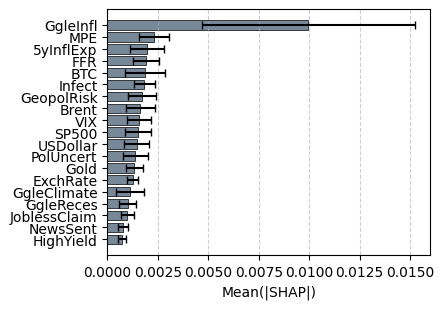

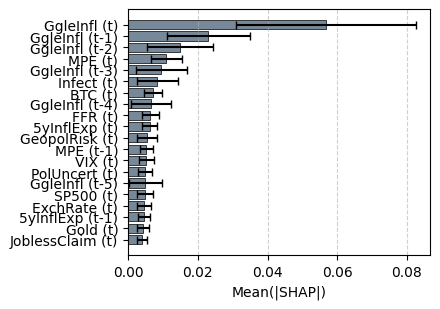


==================== FOLD2 — best search 3 (Mean ± Std of 10 Runs) ====================


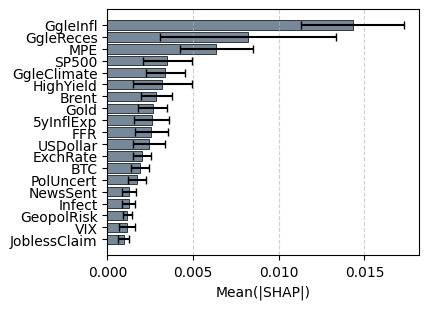

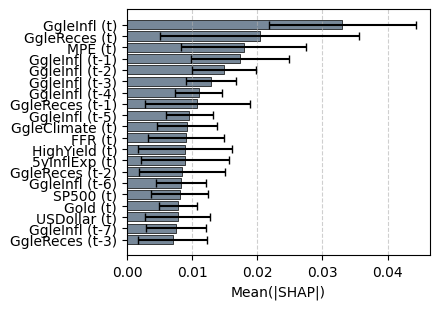


==================== FOLD3 — best search 9 (Mean ± Std of 10 Runs) ====================


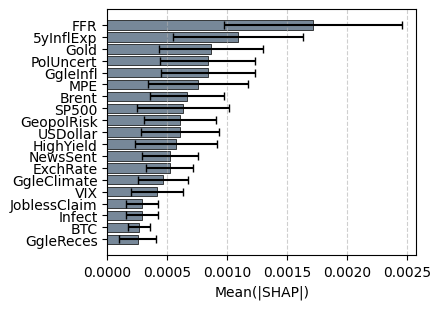

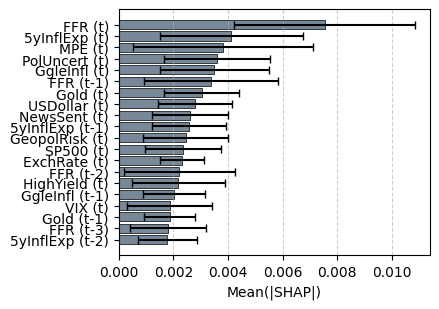


==================== FOLD4 — best search 9 (Mean ± Std of 10 Runs) ====================


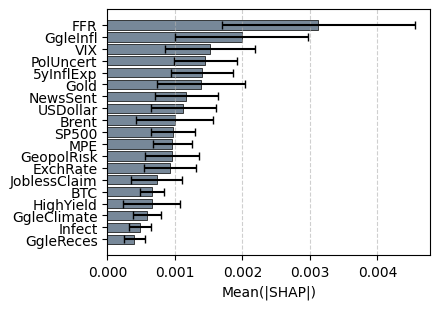

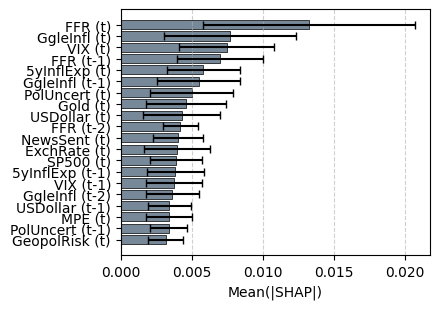

In [14]:

all_fold_rows = []

for fold in FOLDS:
    # v2: only the retraining runs of the fold's best search
    run_dirs = get_run_dirs(fold)

    if not run_dirs: continue

    fold_global_list = []
    fold_diag_list = []

    for fold_dir in run_dirs:
        features = load_meta(fold_dir)
        global_imp, diag_imp = load_shap_detailed(fold_dir, features)
        
        fold_global_list.append(global_imp)
        fold_diag_list.append(diag_imp)
        
        # Collect for global final analysis
        df_run = global_imp.reset_index()
        df_run.columns = ["feature", "mean_abs_shap"]
        df_run["fold"] = fold
        all_fold_rows.append(df_run)

    # Compute per-fold Mean and Std across the best search's runs
    df_global_fold = pd.concat(fold_global_list, axis=1)
    avg_global_imp = df_global_fold.mean(axis=1)
    std_global_imp = df_global_fold.std(axis=1)

    df_diag_fold = pd.concat(fold_diag_list, axis=1)
    avg_diag_imp = df_diag_fold.mean(axis=1)
    std_diag_imp = df_diag_fold.std(axis=1)

    # Map names for plotting
    avg_global_mapped = avg_global_imp.rename(index=lambda x: names.get(x, x))
    std_global_mapped = std_global_imp.rename(index=lambda x: names.get(x, x))

    print(f"\n{'='*20} {fold.upper()} — best search {BEST_SEARCH[fold]} "
          f"(Mean ± Std of {len(run_dirs)} Runs) {'='*20}")
    
    # Plot per-fold aggregated with error bars
    plot_importance_with_err(avg_global_mapped, std_global_mapped, TOP_N)
    plt.tight_layout()
    plt.savefig(f"figures/shap_fold_{fold[-1]}.pdf")
    plt.show()

    # Plot per-fold disaggregated with error bars
    plot_importance_with_err(avg_diag_imp, std_diag_imp, TOP_N)
    plt.tight_layout()
    plt.xlim([0, None])
    plt.savefig(f"figures/shap_lag_fold_{fold[-1]}.pdf")
    plt.show()

### **4) Cross-Fold Aggregation & LaTeX Reporting** <a id="4-fold--latex"></a>


In [15]:
# Global Aggregated Table 
# Combine the results collected in the main loop
global_abs_df = pd.concat(all_fold_rows, ignore_index=True)

# Map raw codes to academic names
global_abs_df["academic_name"] = global_abs_df["feature"].map(names).fillna(global_abs_df["feature"])

# Pivot for Mean and Std simultaneously
pivot_stats = global_abs_df.pivot_table(
    index="academic_name",
    columns="fold",
    values="mean_abs_shap",
    aggfunc=["mean", "std"]
).fillna(0.0)

# Calculate Overall Mean and Std across all folds/runs
overall_mean = global_abs_df.groupby("academic_name")["mean_abs_shap"].mean()
overall_std = global_abs_df.groupby("academic_name")["mean_abs_shap"].std().fillna(0.0)

# Create the formatted DataFrame
df_formatted = pd.DataFrame(index=pivot_stats.index)

# Calculate Rank based on the overall mean
df_formatted["rank"] = overall_mean.rank(ascending=False, method="dense").astype(int)

# Add Formatted Overall Average: Mean (SD)
df_formatted["avg_importance"] = [f"{m:.3f} ({s:.3f})" for m, s in zip(overall_mean, overall_std)]

# Add Formatted Per-Fold Columns: Mean (SD)
fold_names = sorted(global_abs_df["fold"].unique())
for fld in fold_names:
    means = pivot_stats["mean"][fld]
    stds = pivot_stats["std"][fld]
    df_formatted[fld] = [f"{m:.3f} ({s:.3f})" for m, s in zip(means, stds)]

# Sort by Rank
df_ranked_global = df_formatted.sort_values("rank")

print("Table: Global Feature Importance (Aggregated across Lags) - Mean (SD)")
display(df_ranked_global.head(20))


Table: Global Feature Importance (Aggregated across Lags) - Mean (SD)


,rank,avg_importance,fold1,fold2,fold3,fold4
academic_name,,,,,,
GgleInfl,1,0.007 (0.006),0.010 (0.005),0.014 (0.003),0.001 (0.000),0.002 (0.001)
MPE,2,0.003 (0.003),0.002 (0.001),0.006 (0.002),0.001 (0.000),0.001 (0.000)
GgleReces,3,0.002 (0.004),0.001 (0.000),0.008 (0.005),0.000 (0.000),0.000 (0.000)
FFR,4,0.002 (0.001),0.002 (0.001),0.003 (0.001),0.002 (0.001),0.003 (0.001)
5yInflExp,5,0.002 (0.001),0.002 (0.001),0.003 (0.001),0.001 (0.001),0.001 (0.000)
SP500,6,0.002 (0.001),0.002 (0.001),0.004 (0.001),0.001 (0.000),0.001 (0.000)
Gold,7,0.002 (0.001),0.001 (0.000),0.003 (0.001),0.001 (0.000),0.001 (0.001)
Brent,8,0.002 (0.001),0.002 (0.001),0.003 (0.001),0.001 (0.000),0.001 (0.001)
USDollar,9,0.001 (0.001),0.001 (0.001),0.002 (0.001),0.001 (0.000),0.001 (0.000)


In [16]:
df_global_latex = df_ranked_global.head(20).copy()

# Italicize the index and escape underscores
df_global_latex.index = df_global_latex.index.map(
    lambda x: f"\\textit{{{str(x).replace('_', '\\_')}}}"
)

latex_str = df_global_latex.to_latex(
    caption="Global Feature Importance: Mean Absolute SHAP Values (SD in Parentheses)",
    label="tab:global_shap_sd",
    column_format="l c l " + "l"*len(fold_names),
    escape=False  # Required to interpret \textit and \_ correctly
)

print(latex_str)

\begin{table}
\caption{Global Feature Importance: Mean Absolute SHAP Values (SD in Parentheses)}
\label{tab:global_shap_sd}
\begin{tabular}{l c l llll}
\toprule
 & rank & avg_importance & fold1 & fold2 & fold3 & fold4 \\
academic_name &  &  &  &  &  &  \\
\midrule
\textit{GgleInfl} & 1 & 0.007 (0.006) & 0.010 (0.005) & 0.014 (0.003) & 0.001 (0.000) & 0.002 (0.001) \\
\textit{MPE} & 2 & 0.003 (0.003) & 0.002 (0.001) & 0.006 (0.002) & 0.001 (0.000) & 0.001 (0.000) \\
\textit{GgleReces} & 3 & 0.002 (0.004) & 0.001 (0.000) & 0.008 (0.005) & 0.000 (0.000) & 0.000 (0.000) \\
\textit{FFR} & 4 & 0.002 (0.001) & 0.002 (0.001) & 0.003 (0.001) & 0.002 (0.001) & 0.003 (0.001) \\
\textit{5yInflExp} & 5 & 0.002 (0.001) & 0.002 (0.001) & 0.003 (0.001) & 0.001 (0.001) & 0.001 (0.000) \\
\textit{SP500} & 6 & 0.002 (0.001) & 0.002 (0.001) & 0.004 (0.001) & 0.001 (0.000) & 0.001 (0.000) \\
\textit{Gold} & 7 & 0.002 (0.001) & 0.001 (0.000) & 0.003 (0.001) & 0.001 (0.000) & 0.001 (0.001) \\
\textit{Brent} 

### **5) Temporal Dynamics** <a id="5-temporal"></a>


In [17]:
diag_run_rows = []

# v2: iterate only over the best search's run dirs of each fold
for base_fold in FOLDS:
    for run_path in get_run_dirs(base_fold):
        run_folder = os.path.basename(run_path)

        features = load_meta(run_path)
        _, diag_imp = load_shap_detailed(run_path, features)

        df_diag = diag_imp.reset_index()
        df_diag.columns = ["feature_lag", "importance"]
        df_diag["base_fold"] = base_fold
        df_diag["run_folder"] = run_folder
        diag_run_rows.append(df_diag)

diag_all_runs_df = pd.concat(diag_run_rows, ignore_index=True)

pivot_diag_stats = diag_all_runs_df.pivot_table(
    index="feature_lag",
    columns="base_fold",
    values="importance",
    aggfunc=["mean", "std"]
).fillna(0.0)

overall_diag_mean = diag_all_runs_df.groupby("feature_lag")["importance"].mean()
overall_diag_std = diag_all_runs_df.groupby("feature_lag")["importance"].std().fillna(0.0)

df_diag_formatted = pd.DataFrame(index=pivot_diag_stats.index)

# Calculate Rank based on overall importance
df_diag_formatted["rank"] = overall_diag_mean.rank(ascending=False, method="dense").astype(int)

# Add Formatted Overall Average: Mean (SD)
df_diag_formatted["avg_importance"] = [
    f"{m:.3f} ({s:.3f})" for m, s in zip(overall_diag_mean, overall_diag_std)
]

# Add Formatted Per-Fold Columns: Mean (SD)
base_folds = sorted(diag_all_runs_df["base_fold"].unique())
for fld in base_folds:
    means = pivot_diag_stats["mean"][fld]
    stds = pivot_diag_stats["std"][fld]
    df_diag_formatted[fld] = [f"{m:.3f} ({s:.3f})" for m, s in zip(means, stds)]

df_ranked_diag_final = df_diag_formatted.sort_values("rank")

print("Table: Disaggregated Feature-Lag Importance - Mean (SD across best-search runs)")
display(df_ranked_diag_final.head(20))

Table: Disaggregated Feature-Lag Importance - Mean (SD across best-search runs)


,rank,avg_importance,fold1,fold2,fold3,fold4
feature_lag,,,,,,
GgleInfl (t),1,0.025 (0.026),0.057 (0.026),0.033 (0.011),0.004 (0.002),0.008 (0.005)
GgleInfl (t-1),2,0.012 (0.011),0.023 (0.012),0.017 (0.008),0.002 (0.001),0.005 (0.003)
FFR (t),3,0.009 (0.006),0.006 (0.002),0.009 (0.006),0.008 (0.003),0.013 (0.007)
MPE (t),4,0.009 (0.008),0.011 (0.004),0.018 (0.010),0.004 (0.003),0.003 (0.002)
GgleInfl (t-2),5,0.009 (0.008),0.015 (0.010),0.015 (0.005),0.001 (0.001),0.004 (0.002)
GgleReces (t),6,0.007 (0.011),0.004 (0.002),0.020 (0.015),0.001 (0.000),0.002 (0.001)
GgleInfl (t-3),7,0.006 (0.006),0.010 (0.007),0.013 (0.004),0.001 (0.000),0.002 (0.001)
5yInflExp (t),8,0.006 (0.004),0.006 (0.002),0.009 (0.007),0.004 (0.003),0.006 (0.003)
GgleInfl (t-4),9,0.005 (0.005),0.007 (0.006),0.011 (0.004),0.001 (0.000),0.002 (0.001)


In [18]:
# Apply italics to the index values directly
df_ranked_diag_final.index = df_ranked_diag_final.index.map(lambda x: f"\\textit{{{x}}}")

latex_diag = df_ranked_diag_final.head(20).to_latex(
    column_format="l c l " + "c"*len(base_folds),
    caption="Disaggregated Feature-Lag Importance: Mean Absolute SHAP (SD)",
    label="tab:diag_shap_sd",
    header=["Rank", "Average (SD)", "Fold 1", "Fold 2", "Fold 3", "Fold 4"],
    escape=False  # This is crucial so LaTeX doesn't escape the backslashes
)

print(latex_diag)

\begin{table}
\caption{Disaggregated Feature-Lag Importance: Mean Absolute SHAP (SD)}
\label{tab:diag_shap_sd}
\begin{tabular}{l c l cccc}
\toprule
 & Rank & Average (SD) & Fold 1 & Fold 2 & Fold 3 & Fold 4 \\
feature_lag &  &  &  &  &  &  \\
\midrule
\textit{GgleInfl (t)} & 1 & 0.025 (0.026) & 0.057 (0.026) & 0.033 (0.011) & 0.004 (0.002) & 0.008 (0.005) \\
\textit{GgleInfl (t-1)} & 2 & 0.012 (0.011) & 0.023 (0.012) & 0.017 (0.008) & 0.002 (0.001) & 0.005 (0.003) \\
\textit{FFR (t)} & 3 & 0.009 (0.006) & 0.006 (0.002) & 0.009 (0.006) & 0.008 (0.003) & 0.013 (0.007) \\
\textit{MPE (t)} & 4 & 0.009 (0.008) & 0.011 (0.004) & 0.018 (0.010) & 0.004 (0.003) & 0.003 (0.002) \\
\textit{GgleInfl (t-2)} & 5 & 0.009 (0.008) & 0.015 (0.010) & 0.015 (0.005) & 0.001 (0.001) & 0.004 (0.002) \\
\textit{GgleReces (t)} & 6 & 0.007 (0.011) & 0.004 (0.002) & 0.020 (0.015) & 0.001 (0.000) & 0.002 (0.001) \\
\textit{GgleInfl (t-3)} & 7 & 0.006 (0.006) & 0.010 (0.007) & 0.013 (0.004) & 0.001 (0.000) & 0.002

### **6) Global Aggregated SHAP Plot** <a id="6-global--agg--shap"></a>


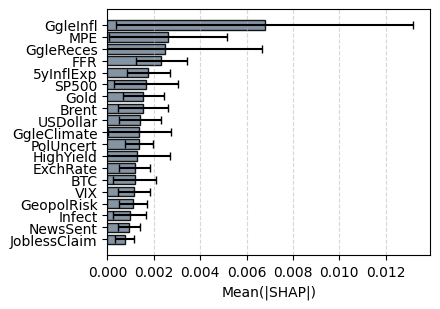

In [19]:
df_all_global = pd.concat(all_fold_rows, ignore_index=True)

stats_global = (
    df_all_global.groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=True) # Ascending for horizontal bar plot
)

stats_global.index = stats_global.index.map(lambda x: names.get(x, x))

plt.figure(figsize=(4.5, 3.2))
plt.barh(
    stats_global.tail(TOP_N).index, 
    stats_global.tail(TOP_N)["mean"],
    xerr=stats_global.tail(TOP_N)["std"],
    capsize=3, color="lightslategray", edgecolor="black", linewidth=1, alpha=0.9
)

plt.xlabel("Mean(|SHAP|)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim([0,None])
plt.tight_layout()
plt.savefig(f"figures/shap_avg.pdf")
plt.show()
    

### **7) Global Disaggregated SHAP Plot** <a id="7-global--disagg--shap"></a>


Top 20 Disaggregated Features (Aggregated)


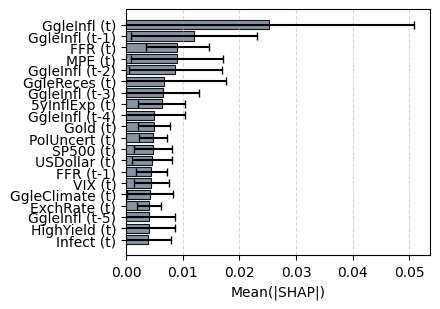

In [20]:
TOP_N_LAG = 20

if 'diag_all_runs_df' in locals():
    df_plot_diag = diag_all_runs_df.copy()
else:
    # Fallback/Safety: Combine all rows if not already done
    df_plot_diag = pd.concat(diag_run_rows, ignore_index=True)

stats_diag = (
    df_plot_diag.groupby("feature_lag")["importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=True)
)

plt.figure(figsize=(4.5, 3.2))
top_stats = stats_diag.tail(TOP_N_LAG)

plt.barh(
    top_stats.index, 
    top_stats["mean"],
    xerr=top_stats["std"], # Error bar now shows variation across all runs/folds
    capsize=3, 
    color="lightslategray", 
    edgecolor="black", 
    linewidth=0.8, 
    alpha=0.9
)

plt.xlabel("Mean(|SHAP|)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim([0, None])

# Add a subtle title to indicate aggregation
print(f"Top {TOP_N_LAG} Disaggregated Features (Aggregated)")
plt.tight_layout()
plt.savefig("figures/shap_lag_avg.pdf", bbox_inches='tight')
plt.show()

### **8) Importance by Feature and Lag** <a id="8-importance--lag"></a>

In [21]:
profile_data = []

top_features = df_ranked_global.head(15).index

# and contains the 'avg_importance' column.
for feat in top_features:
    # We search the index of df_ranked_diag_final for the feature name
    # e.g., finding "Btc (t)", "Btc (t-1)" by searching for "Btc"
    feat_lags = df_ranked_diag_final[df_ranked_diag_final.index.str.contains(feat, regex=False)].copy()
    
    if feat_lags.empty:
        continue
        
    # Convert 'avg_importance' back to float (it was a string "Mean (SD)")
    # We extract the mean part before the parenthesis
    feat_lags['numeric_imp'] = feat_lags['avg_importance'].apply(lambda x: float(x.split(' ')[0]))
    feat_lags = feat_lags.sort_values("numeric_imp", ascending=False)
    
    total_feat_imp = feat_lags["numeric_imp"].sum()
    feat_lags["share"] = feat_lags["numeric_imp"] / total_feat_imp
    
    significant_lags = []
    cum_share = 0
    for idx, row in feat_lags.iterrows():
        # Extract lag: "USDollar (t-1)" -> "t-1"
        lag_label = idx.split('(')[-1].replace(')', '').strip()
        significant_lags.append(lag_label)
        cum_share += row["share"]
        if cum_share > 0.8: 
            break
    
    top_share = feat_lags["share"].iloc[0]
    profile = "Sharp" if top_share > 0.6 else "Gradual"
    
    profile_data.append({
        "Feature": feat,
        "Significant Lags": ", ".join(significant_lags),
        "Temporal Profile": profile,
        "Top Lag Share": f"{top_share:.1%}"
    })

df_profile = pd.DataFrame(profile_data)
display(df_profile)

,Feature,Significant Lags,Temporal Profile,Top Lag Share
0,GgleInfl,"t}, t-1}, t-2}, t-3}, t-4}",Gradual,35.2%
1,MPE,"t}, t-1}, t-2}, t-3}, t-4}, t-5}",Gradual,36.0%
2,GgleReces,"t}, t-1}, t-2}, t-3}, t-4}",Gradual,31.8%
3,FFR,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}, t-7}",Gradual,32.1%
4,5yInflExp,"t}, t-1}, t-2}, t-3}, t-4}, t-5}",Gradual,31.6%
5,SP500,"t}, t-1}, t-2}, t-3}, t-4}",Gradual,31.2%
6,Gold,"t}, t-1}, t-2}, t-3}, t-4}, t-5}",Gradual,29.4%
7,Brent,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}",Gradual,18.7%
8,USDollar,"t}, t-1}, t-2}, t-3}, t-4}, t-5}",Gradual,33.3%
9,GgleClimate,"t}, t-1}, t-2}, t-3}, t-4}, t-5}",Gradual,30.8%


### **9) Top 10 Features: Importance and Lag** <a id="9-top10--features"></a>

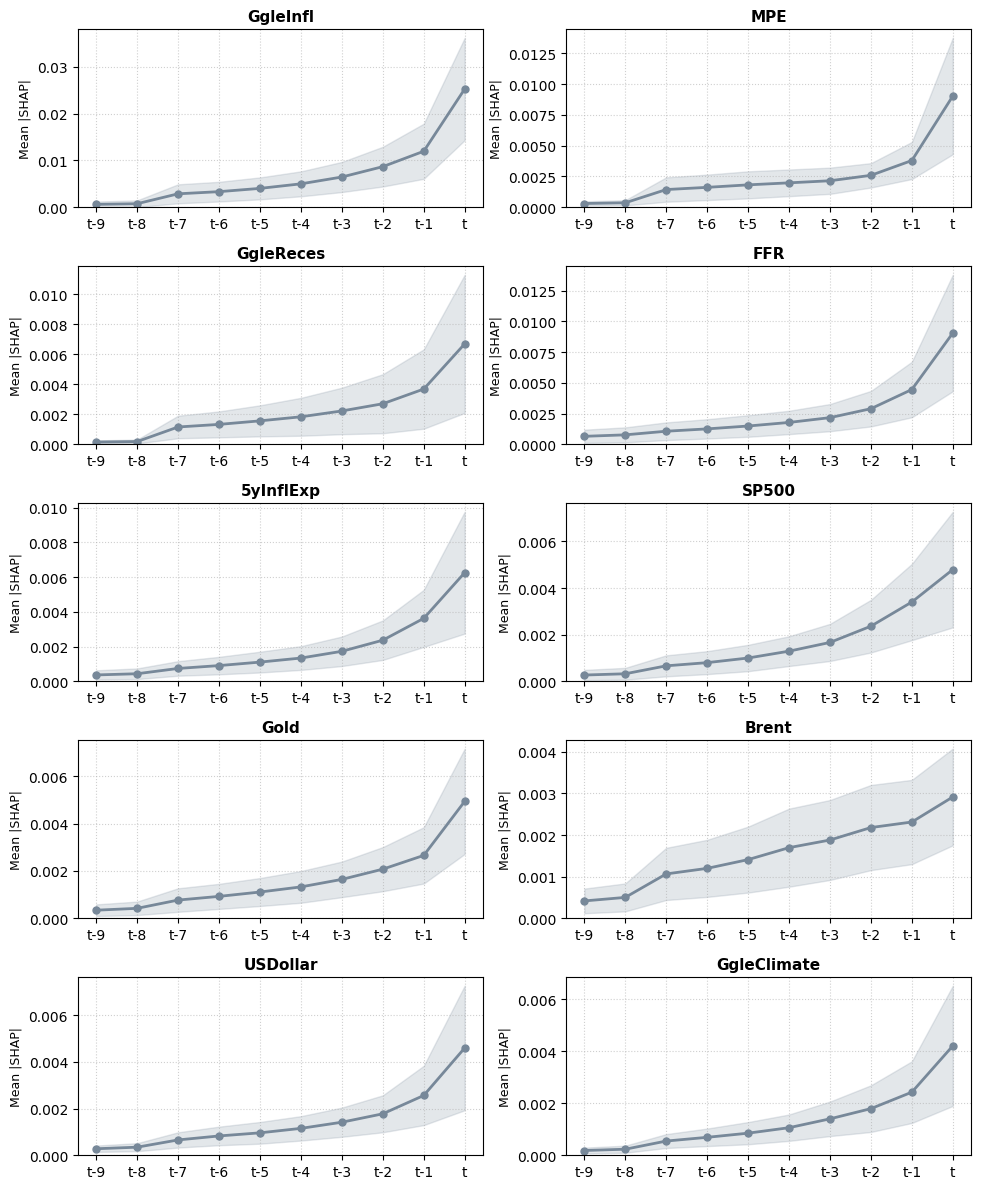

In [22]:
# Identify top 10 features from the GLOBAL ranked results
top_10_global = df_ranked_global.head(10).index.tolist()

plot_df = pivot_diag_stats.copy()

def parse_index(idx):
    base_name = idx.split(' (')[0]
    if '(t)' in idx: 
        return base_name, 0
    match = re.search(r'\(t-(\d+)\)', idx)
    return base_name, int(match.group(1)) if match else 0

parsed = [parse_index(i) for i in plot_df.index]
plot_df['base_feature'] = [p[0] for p in parsed]
plot_df['lag_idx'] = [p[1] for p in parsed]

# We look inside one of the MultiIndex levels to get these strings
fold_names = plot_df.columns.get_level_values(1).unique()
fold_names = [f for f in fold_names if 'fold' in str(f)]

# Plot
fig, axes = plt.subplots(5, 2, figsize=(10, 12)) # Slightly larger for clarity
axes = axes.flatten()

for i, feature in enumerate(top_10_global):
    ax = axes[i]
    
    # Filter for the feature and sort lags: oldest (t-n) to newest (t)
    subset = plot_df[plot_df['base_feature'] == feature].copy()
    subset = subset.sort_values('lag_idx', ascending=False)
    subset = subset.tail(10)
    # ------------------------------------------------

    if subset.empty:
        continue

    # .xs('mean', axis=1) isolates just the mean columns for all folds
    means_per_fold = subset.xs('mean', axis=1, level=0)[fold_names]
    stds_per_fold = subset.xs('std', axis=1, level=0)[fold_names]
    
    # Calculate the cross-fold average and the cross-fold uncertainty
    mean_val = means_per_fold.mean(axis=1).values
    std_val = stds_per_fold.mean(axis=1).values 
    
    x_labels = [f"t-{int(l)}" if l > 0 else "t" for l in subset['lag_idx']]
    
    ax.plot(x_labels, mean_val, marker='o', color='lightslategray', 
            linewidth=2, markersize=5, label='Mean SHAP')
    ax.fill_between(x_labels, mean_val - std_val, mean_val + std_val, 
                    alpha=0.2, color='lightslategray')
    
    ax.set_title(f"{feature}", fontweight='bold', fontsize=11)
    ax.set_ylabel("Mean |SHAP|", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(0, None) 

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/temporal_signatures.pdf", bbox_inches='tight')
plt.show()

### **9) Top 10 Features: Importance and Lag (Aggregated)** <a id="9-top10--features--agg"></a>

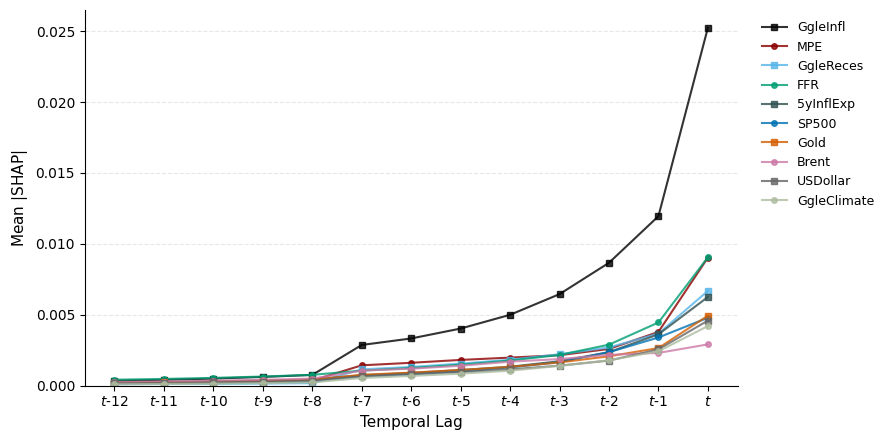

In [23]:
# Identify top 10 features from the GLOBAL ranked results
top_10_global = df_ranked_global.head(10).index.tolist()

plot_df = pivot_diag_stats.copy()

# Re-apply parsing
def parse_index(idx):
    base_name = idx.split(' (')[0]
    if '(t)' in idx: return base_name, 0
    match = re.search(r'\(t-(\d+)\)', idx)
    return base_name, int(match.group(1)) if match else 0

parsed = [parse_index(i) for i in plot_df.index]
plot_df['base_feature'] = [p[0] for p in parsed]
plot_df['lag_idx'] = [p[1] for p in parsed]

# Identify the fold columns specifically within the 'mean' level
fold_names = plot_df.columns.get_level_values(1).unique()
fold_names = [f for f in fold_names if 'fold' in str(f)]

list_colors = [
    "#000000", "#8B0000", "#56B4E9", "#009E73",  
    "#2F4F4F", "#0072B2", "#D55E00", "#CC79A7",  
    "#666666", "#ADBC9F"
]

plt.figure(figsize=(9, 4.5))

for i, feature in enumerate(top_10_global):
    subset = plot_df[plot_df['base_feature'] == feature].copy()
    subset = subset.sort_values('lag_idx', ascending=False)
    
    if subset.empty: continue
    
    # isolate the 'mean' level for plotting
    means_across_folds = subset.xs('mean', axis=1, level=0)[fold_names].mean(axis=1).values
    
    x_labels = [f"$t$-{int(l)}" if l > 0 else "$t$" for l in subset['lag_idx']]
    
    # Plotting
    plt.plot(x_labels, means_across_folds, 
             label=feature, 
             color=list_colors[i % len(list_colors)],
             linewidth=1.5, 
             marker='s' if i % 2 == 0 else 'o', 
             markersize=4,
             alpha=0.8)

plt.ylabel("Mean $|$SHAP$|$", fontsize=11)
plt.xlabel("Temporal Lag", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3) 
plt.gca().spines['top'].set_visible(False) 
plt.gca().spines['right'].set_visible(False) 
plt.ylim(0, None)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/combined_signatures.pdf", bbox_inches='tight')
plt.show()

### **10) Regime-Dependent Interaction Analysis MPE and FFR** <a id="10-interactions"></a>

FOLD1 Interaction


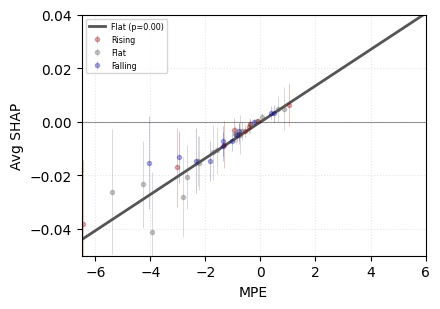

FOLD2 Interaction


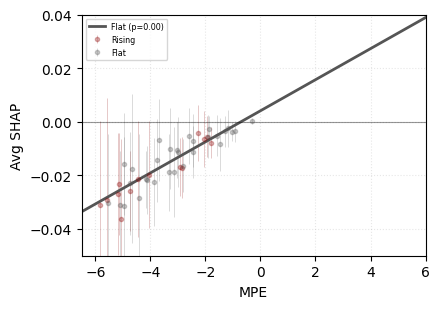

FOLD3 Interaction


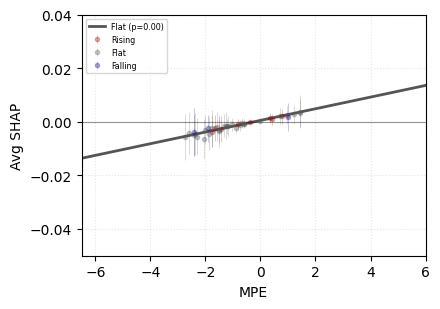

FOLD4 Interaction


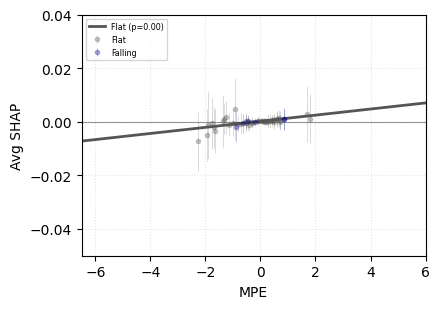

In [24]:
def run_interaction_analysis(target_feat="mp_exp", interact_feat="ffr"):
    colors = {"Rising": "#8b0000", "Flat": "#555555", "Falling": "#00008b"}

    for fold in FOLDS:
        run_dirs = get_run_dirs(fold)

        if not run_dirs: continue

        all_X, all_shap = [], []
        features = None

        for fold_dir in run_dirs:
            if features is None: features = load_meta(fold_dir)

            # to_3d drops trailing singleton axes by indexing, not reshape.
            # load_shap_values validates the cache against X_explain, so a stale
            # shap_values.npy from an earlier training pass is recomputed.
            x_3d = to_3d(np.load(os.path.join(fold_dir, "X_explain.npy")))
            s_3d = load_shap_values(fold_dir)

            all_X.append(x_3d)
            all_shap.append(s_3d)

        # All runs of a single Optuna search share hyperparameters, so every run
        # must have identical (samples, lookback, features).
        shapes = {x.shape for x in all_X} | {s.shape for s in all_shap}
        if len(shapes) != 1:
            raise ValueError(
                f"{fold}: inconsistent shapes across runs of search "
                f"{BEST_SEARCH[fold]}: {sorted(shapes)}")

        # Stack runs on a new leading axis: (runs, samples, lags, features)
        X_aligned = np.stack(all_X, axis=0)
        shp_aligned = np.stack(all_shap, axis=0)

        # Average across the best search's runs
        X_mean = np.mean(X_aligned, axis=0)
        shp_mean = np.mean(shp_aligned, axis=0)
        shp_std = np.std(shp_aligned, axis=0)

        t_idx, i_idx = features.index(target_feat), features.index(interact_feat)
        ffr_delta = X_mean[:, -1, i_idx] - X_mean[:, -2, i_idx]

        df_avg = pd.DataFrame({
            "Sentiment": (X_mean[:, -1, t_idx]) ,
            "SHAP_Mean": shp_mean[:, -1, t_idx],
            "SHAP_Std": shp_std[:, -1, t_idx],
            "FFR_Change": ffr_delta
        })

        df_avg["Regime"] = pd.cut(df_avg["FFR_Change"], 
                                   bins=[-np.inf, -0.0001, 0.0001, np.inf], 
                                   labels=["Falling", "Flat", "Rising"], include_lowest=True)

        # Winsorize and Plot
        df_avg["Sentiment"] = winsorize(df_avg["Sentiment"], limits=[0.01, 0.01])
        df_avg["SHAP_Mean"] = winsorize(df_avg["SHAP_Mean"], limits=[0.01, 0.01])

        plt.figure(figsize=(4.5, 3.2))

        for label, color in colors.items():
            subset = df_avg[df_avg["Regime"] == label]
            if subset.empty: continue
            plt.errorbar(subset["Sentiment"], subset["SHAP_Mean"], yerr=subset["SHAP_Std"],
                         fmt='o', color=color, markersize=3, elinewidth=0.5, alpha=0.3, 
                         label=f"{label}", linestyle='None')

        x_range = np.linspace(-10, 10, 100)
        for label in ["Rising", "Flat", "Falling"]:
            subset = df_avg[df_avg["Regime"] == label]
            if len(subset) > 15:
                slope, intercept, r, p, se = stats.linregress(subset["Sentiment"], subset["SHAP_Mean"])
                if p < 0.05:
                    plt.plot(x_range, slope * x_range + intercept, color=colors[label], linewidth=2,
                             label=f"{label} (p={p:.2f})")

        plt.axhline(0, color='black', lw=0.8, alpha=0.4)
        print(f"{fold.upper()} Interaction")
        plt.xlabel("MPE")
        plt.ylabel("Avg SHAP")
        plt.ylim([-0.05,0.04])
        plt.xlim([-6.5,6])
        plt.legend(fontsize='xx-small', loc='upper left'); plt.grid(True, ls=':', alpha=0.3)
        plt.tight_layout(); plt.savefig(f"figures/shap_interaction_{fold}.pdf"); plt.show()

run_interaction_analysis(target_feat="mp_exp", interact_feat="ffr")

### **11) Regime-Dependent Interaction Analysis MPE and FFR (Aggregated)** <a id="11-interactions--agg"></a>

Global Interaction Analysis (Averaged Runs per Observation)


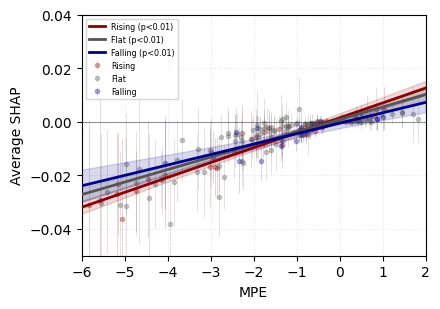

In [25]:
def plot_rescaled_global_interaction(target_feat="mp_exp", interact_feat="ffr"):
    # Small epsilon for "Flat" regime since we are now calculating deltas
    FLAT_THRESHOLD = 0.0001 
    colors = {"Rising": "#8b0000", "Flat": "#555555", "Falling": "#00008b"}
    
    all_fold_averages = []

    for fold in FOLDS:
        run_dirs = get_run_dirs(fold)

        if not run_dirs: continue
        
        fold_X_list = []
        fold_shp_list = []
        features = None

        for fold_dir in run_dirs:
            if features is None:
                features = load_meta(fold_dir)

            # to_3d drops trailing singleton axes by indexing; load_shap_values
            # rejects a cache that disagrees with this run's X_explain.
            X_ex = to_3d(np.load(os.path.join(fold_dir, "X_explain.npy")))
            shp  = load_shap_values(fold_dir)

            fold_X_list.append(X_ex)
            fold_shp_list.append(shp)

        # Runs of one search are replicates and must share (samples, lags, features).
        shapes = {x.shape for x in fold_X_list} | {s.shape for s in fold_shp_list}
        if len(shapes) != 1:
            raise ValueError(
                f"{fold}: inconsistent shapes across runs of search "
                f"{BEST_SEARCH[fold]}: {sorted(shapes)}")

        # Stack along a NEW axis (Runs, Samples, Lags, Features)
        # This allows us to calculate the mean/std PER observation across the runs
        X_aligned = np.stack(fold_X_list, axis=0)
        shp_aligned = np.stack(fold_shp_list, axis=0)

        # Calculate Mean and Std across runs (axis 0)
        X_mean = np.mean(X_aligned, axis=0)
        shp_mean = np.mean(shp_aligned, axis=0)
        shp_std = np.std(shp_aligned, axis=0)

        t_idx = features.index(target_feat)
        i_idx = features.index(interact_feat)

        # Correct Delta logic for FFR
        ffr_delta = X_mean[:, -1, i_idx] - X_mean[:, -2, i_idx]
        
        # Reconstruct unscaled sentiment
        original_sentiment = (X_mean[:, -1, t_idx] )

        df_fold = pd.DataFrame({
            "Sentiment": original_sentiment,
            "SHAP_Mean": shp_mean[:, -1, t_idx],
            "SHAP_Std": shp_std[:, -1, t_idx],
            "FFR_Change": ffr_delta
        })
        all_fold_averages.append(df_fold)

    # Concatenate all averaged folds
    df_global = pd.concat(all_fold_averages, ignore_index=True)

    # Define Regimes based on average FFR delta
    df_global["Regime"] = pd.cut(df_global["FFR_Change"], 
                                 bins=[-np.inf, -FLAT_THRESHOLD, FLAT_THRESHOLD, np.inf], 
                                 labels=["Falling", "Flat", "Rising"], 
                                 include_lowest=True)

    # Winsorize for visual clarity
    df_global["SHAP_Mean"] = winsorize(df_global["SHAP_Mean"], limits=[0.01, 0.01])

    plt.figure(figsize=(4.5, 3.2))
    
    # Plot averaged points with Error Bars
    for label, color in colors.items():
        subset = df_global[df_global["Regime"] == label]
        if subset.empty: continue
        
        plt.errorbar(
            subset["Sentiment"], subset["SHAP_Mean"], yerr=subset["SHAP_Std"],
            fmt='o', color=color, markersize=3, elinewidth=0.4, capsize=0, 
            alpha=0.3, label=f"{label}", linestyle='None', zorder=1
        )

    # Global Regression on the Averaged Data
    x_range = np.linspace(df_global["Sentiment"].min(), 2, 100) 

    for label in ["Rising", "Flat", "Falling"]:
        subset = df_global[df_global["Regime"] == label]
        if len(subset) < 20: continue
        
        color = colors[label]
        slope, intercept, r_val, p_val, std_err = stats.linregress(subset["Sentiment"], subset["SHAP_Mean"])
        
        if p_val < 0.01:
            y_range = slope * x_range + intercept
            
            # Confidence Interval Calculation
            n = len(subset)
            x_m = subset["Sentiment"].mean()
            sse = np.sum((subset["SHAP_Mean"] - (slope * subset["Sentiment"] + intercept))**2)
            std_err_resid = np.sqrt(sse / (n - 2))
            ssx = np.sum((subset["Sentiment"] - x_m)**2)
            se_band = std_err_resid * np.sqrt(1/n + (x_range - x_m)**2 / ssx)
            t_val = stats.t.ppf(0.975, n - 2)
            
            plt.fill_between(x_range, y_range - t_val * se_band, y_range + t_val * se_band, 
                             color=color, alpha=0.15, zorder=5)
            plt.plot(x_range, y_range, color=color, linewidth=2, 
                     label=f"{label} (p<0.01)", zorder=10)

    plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
    plt.xlim(-0.6, 0.6) # Adjust limits based on your specific distribution
    
    print("Global Interaction Analysis (Averaged Runs per Observation)")
    plt.xlabel("MPE")
    plt.ylabel("Average SHAP")
    plt.ylim([-0.05,0.04])
    plt.xlim([-6,2])
    plt.legend(frameon=True, loc='best', fontsize='xx-small', ncol=1)
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/shap_interaction_global.pdf")

plot_rescaled_global_interaction()
plt.show()